# CIFAR-10 Image Classification — Comparative Study
## COMP462 Course Project

3 models in a **Linear → Kernel → Deep Learning** progression:

| # | Model | Course? |
|---|---|---|
| 1 | Logistic Regression (One-vs-All) | ✓ |
| 2 | SVM (RBF Kernel) | — |
| 3 | CNN (PyTorch, VGG-style) | ✓ |

Each model fixes what the previous couldn't do: LR sets the linear ceiling, SVM adds non-linearity via the kernel trick, CNN preserves 2D spatial structure via convolutions.

---
## Section 0 — Setup & Imports

In [ ]:
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_recall_fscore_support,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

DATASET_PATH = r'c:\Users\akcay\Documents\Python Projects\comp462\dataset\cifar-10-batches-py'
RANDOM_STATE = 42
CLASS_NAMES  = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck']

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

os.makedirs('results', exist_ok=True)

import sklearn, matplotlib
print(f"numpy      {np.__version__}")
print(f"pandas     {pd.__version__}")
print(f"sklearn    {sklearn.__version__}")
print(f"matplotlib {matplotlib.__version__}")
print(f"seaborn    {sns.__version__}")
print(f"torch      {torch.__version__}")
print(f"Device     {'CUDA' if torch.cuda.is_available() else 'CPU'}")

In [ ]:
metrics_data = {}

def evaluate_and_visualize(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    mcc = matthews_corrcoef(y_true, y_pred)

    metrics_data[name] = {
        "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1, "MCC": mcc,
    }

    print(f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  MCC={mcc:.4f}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # normalized confusion matrix (row = true class, values in %)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true') * 100
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.4, linecolor='grey')
    ax.set_title(f'{name} — Normalized Confusion Matrix (%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.tight_layout()
    slug = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'results/cm_{slug}.png', dpi=120, bbox_inches='tight')
    plt.show()

    # TP/FP/FN/TN per class
    cm = confusion_matrix(y_true, y_pred)
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    tn = cm.sum() - (tp + fp + fn)

    df_tpfp = pd.DataFrame({"TP": tp, "FP": fp, "FN": fn, "TN": tn}, index=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(df_tpfp, annot=True, fmt='d', cmap='YlOrRd',
                ax=ax, linewidths=0.5, linecolor='grey')
    ax.set_title(f'{name} — TP / FP / FN / TN per Class', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'results/tpfp_{slug}.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## Section 1 — Data Loading & Exploratory Data Analysis

The CIFAR-10 dataset is stored as Python pickle files containing flat NumPy arrays.
Each image is represented as a row of 3,072 values: 1,024 red pixels, then 1,024 green,
then 1,024 blue (all stored in row-major order for a 32×32 grid).

In [2]:
def load_batch(fpath):
    """Load a single CIFAR-10 pickle batch."""
    with open(fpath, 'rb') as f:
        d = pickle.load(f, encoding='bytes')
    data   = np.array(d[b'data'],   dtype=np.float32)  # (10000, 3072)
    labels = np.array(d[b'labels'], dtype=np.int64)
    return data, labels

# Load all 5 training batches
batches_X, batches_y = [], []
for i in range(1, 6):
    X_b, y_b = load_batch(os.path.join(DATASET_PATH, f'data_batch_{i}'))
    batches_X.append(X_b)
    batches_y.append(y_b)

X_train_raw = np.vstack(batches_X)          # (50000, 3072)
y_train_raw = np.concatenate(batches_y)     # (50000,)

# Load test batch
X_test_raw, y_test = load_batch(os.path.join(DATASET_PATH, 'test_batch'))

print(f"Training data : {X_train_raw.shape}  dtype={X_train_raw.dtype}  range=[{X_train_raw.min():.0f}, {X_train_raw.max():.0f}]")
print(f"Training labels: {y_train_raw.shape}  classes={np.unique(y_train_raw)}")
print(f"Test data     : {X_test_raw.shape}")
print(f"Test labels   : {y_test.shape}")

Training data : (50000, 3072)  dtype=float32  range=[0, 255]
Training labels: (50000,)  classes=[0 1 2 3 4 5 6 7 8 9]
Test data     : (10000, 3072)
Test labels   : (10000,)


fig, axes = plt.subplots(10, 5, figsize=(10, 20))
fig.suptitle('CIFAR-10 — 5 Random Samples per Class', fontsize=14, fontweight='bold', y=1.01)

for row, cls in enumerate(range(10)):
    idx = np.where(y_train_raw == cls)[0]
    chosen = np.random.choice(idx, 5, replace=False)
    for col, img_idx in enumerate(chosen):
        img = X_train_raw[img_idx].reshape(3, 32, 32).transpose(1, 2, 0).astype(np.uint8)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(CLASS_NAMES[cls], fontsize=11, rotation=0,
                                      labelpad=45, va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('results/viz1_sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

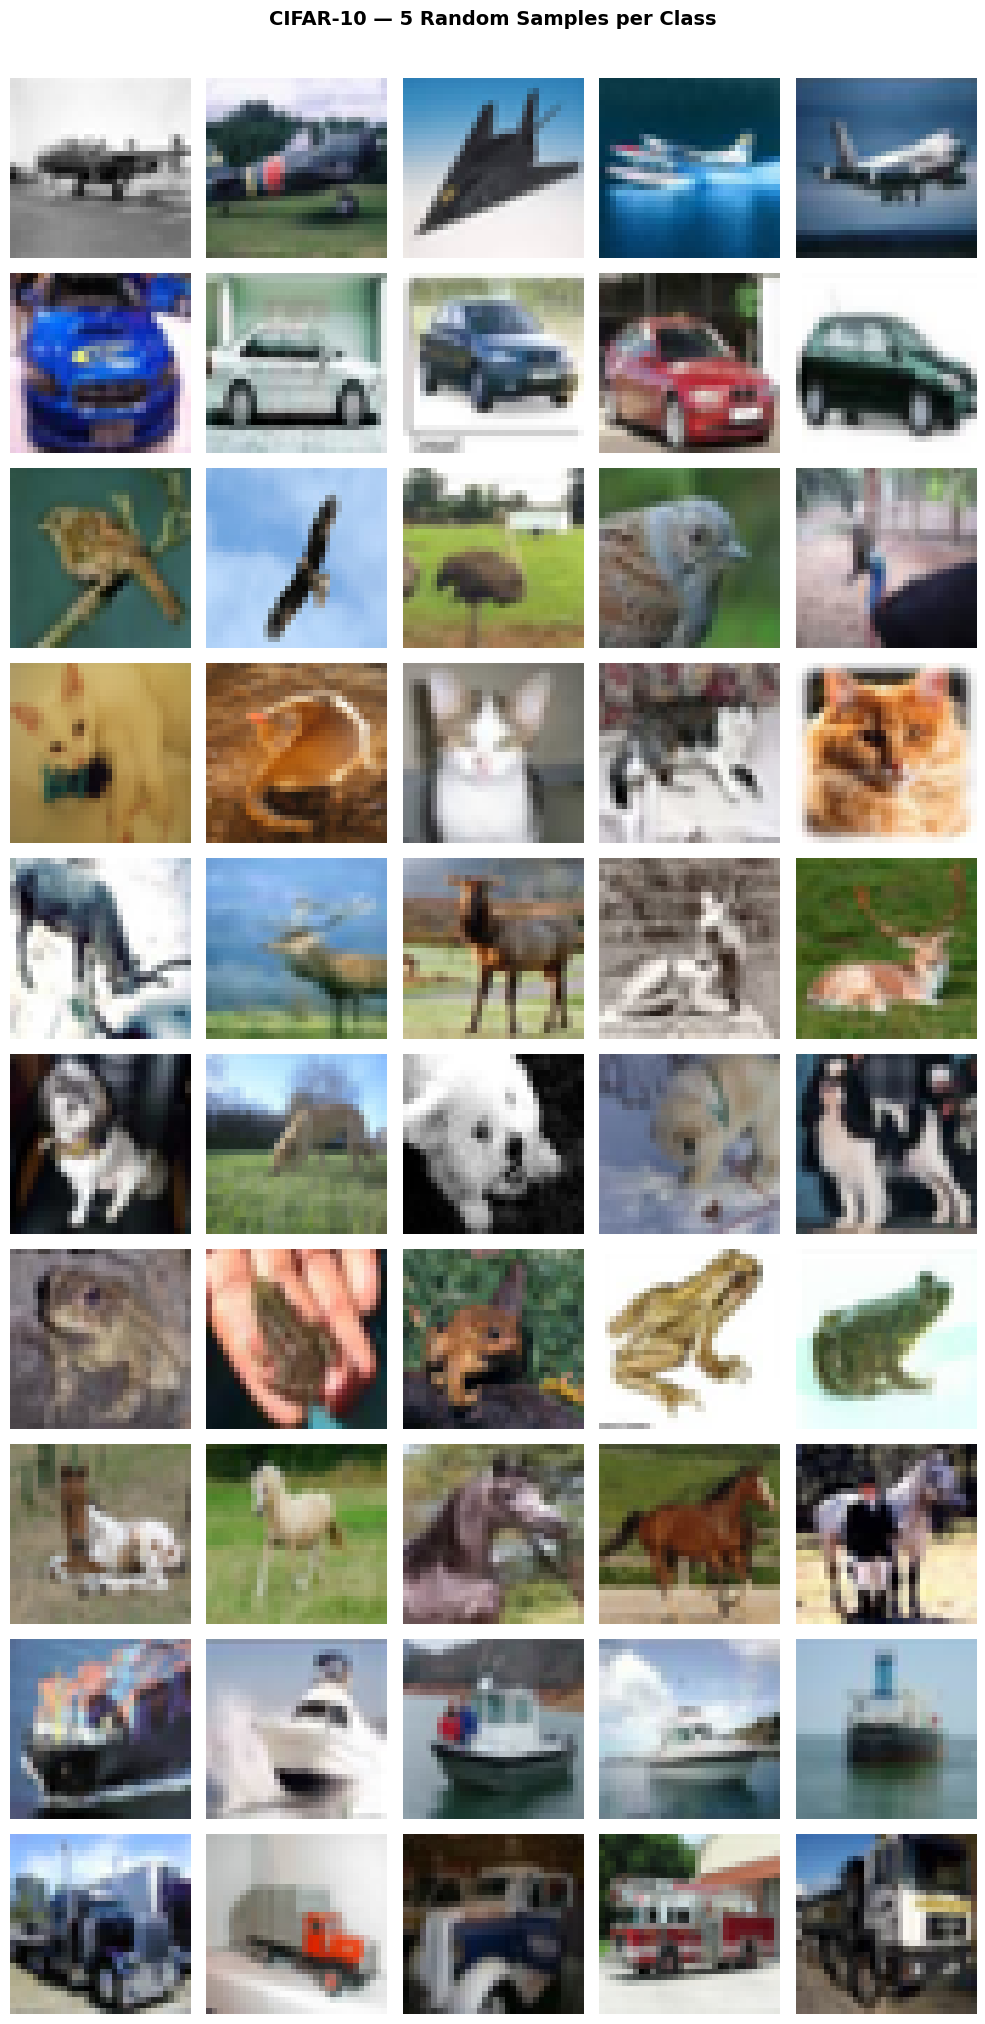

In [3]:
fig, axes = plt.subplots(10, 5, figsize=(10, 20))
fig.suptitle('CIFAR-10 — 5 Random Samples per Class', fontsize=14, fontweight='bold', y=1.01)

for row, cls in enumerate(range(10)):
    idx = np.where(y_train_raw == cls)[0]
    chosen = np.random.choice(idx, 5, replace=False)
    for col, img_idx in enumerate(chosen):
        img = X_train_raw[img_idx].reshape(3, 32, 32).transpose(1, 2, 0).astype(np.uint8)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(CLASS_NAMES[cls], fontsize=11, rotation=0,
                                      labelpad=45, va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('viz1_sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

unique, counts = np.unique(y_train_raw, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASS_NAMES, counts, color=plt.cm.tab10(np.linspace(0, 1, 10)), edgecolor='black', linewidth=0.5)
ax.set_title('CIFAR-10 Class Distribution (Training Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.set_ylim(0, 6000)
ax.axhline(5000, color='red', linestyle='--', linewidth=1, label='5,000 per class')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, cnt + 50, str(cnt),
            ha='center', va='bottom', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('results/viz2_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Classes: {dict(zip(CLASS_NAMES, counts))}")

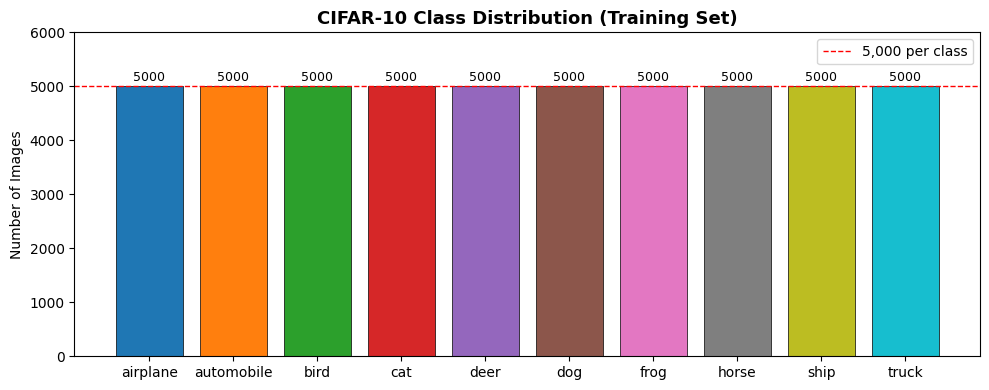

Classes: {'airplane': np.int64(5000), 'automobile': np.int64(5000), 'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}


In [4]:
unique, counts = np.unique(y_train_raw, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASS_NAMES, counts, color=plt.cm.tab10(np.linspace(0, 1, 10)), edgecolor='black', linewidth=0.5)
ax.set_title('CIFAR-10 Class Distribution (Training Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.set_ylim(0, 6000)
ax.axhline(5000, color='red', linestyle='--', linewidth=1, label='5,000 per class')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, cnt + 50, str(cnt),
            ha='center', va='bottom', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('viz2_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Classes: {dict(zip(CLASS_NAMES, counts))}")

---
## Section 2 — Preprocessing Pipeline

Each preprocessing step below is justified with a clear rationale.
The pipeline differs between traditional ML models (LR, SVM) and the CNN:

| Step | LR & SVM | CNN |
|---|---|---|
| Train/Val split | ✓ | ✓ |
| Normalize (per-channel) | ✓ | ✓ |
| PCA (150 components) | ✓ | ✗ |
| Subsample (10k) | SVM only | ✗ |
| Reshape to (N,3,32,32) | ✗ | ✓ |

### Step 2.1 — Train / Validation Split

**Why:** We split the 50,000 training images into 80% train (40,000) and 20% validation (10,000).
The validation set provides an unbiased estimate of generalization performance during
hyperparameter tuning — without touching the official test set.

**Why stratified:** `stratify=y_train_raw` ensures each split maintains the original class
proportions (4,000 per class in train, 1,000 per class in val). Without this, random chance
could create an imbalanced split.

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train_raw,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_raw
)

print(f"X_train : {X_train.shape}   → {np.unique(y_train, return_counts=True)[1]} per class")
print(f"X_val   : {X_val.shape}    → {np.unique(y_val, return_counts=True)[1]} per class")
print(f"X_test  : {X_test_raw.shape}   (untouched until final evaluation)")

X_train : (40000, 3072)   → [4000 4000 4000 4000 4000 4000 4000 4000 4000 4000] per class
X_val   : (10000, 3072)    → [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000] per class
X_test  : (10000, 3072)   (untouched until final evaluation)


### Step 2.2 — Per-Channel Normalization

**Why normalize:** Raw pixel values in [0, 255] cause two problems:
- For **Logistic Regression and CNN**: large feature magnitudes slow gradient convergence
  and cause numerical instability.
- For **SVM**: the RBF kernel computes Euclidean distances — unnormalized channels with
  different means would bias distances toward high-variance channels.

**Why per-channel (not global):** Red, green, and blue channels have different mean pixel
intensities in natural images. Per-channel normalization removes this bias, giving all
three channels equal weight.

**Why compute statistics from training set only:** Computing mean/std from val or test
data would constitute **data leakage** — the model would indirectly "see" test statistics
during training. We apply training-set statistics to all splits.

In [6]:
# CIFAR-10 per-channel statistics (computed from training set)
CIFAR_MEAN = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32)
CIFAR_STD  = np.array([0.2470, 0.2435, 0.2616], dtype=np.float32)

def normalize_flat(X):
    """Normalize flat (N, 3072) CIFAR-10 array per channel."""
    X = X / 255.0
    X[:, :1024]     = (X[:, :1024]     - CIFAR_MEAN[0]) / CIFAR_STD[0]
    X[:, 1024:2048] = (X[:, 1024:2048] - CIFAR_MEAN[1]) / CIFAR_STD[1]
    X[:, 2048:]     = (X[:, 2048:]     - CIFAR_MEAN[2]) / CIFAR_STD[2]
    return X

X_train_norm = normalize_flat(X_train.copy())
X_val_norm   = normalize_flat(X_val.copy())
X_test_norm  = normalize_flat(X_test_raw.copy())

print(f"After normalization — mean: {X_train_norm.mean():.4f}  std: {X_train_norm.std():.4f}")
print(f"Value range: [{X_train_norm.min():.2f}, {X_train_norm.max():.2f}]")

After normalization — mean: -0.0004  std: 1.0001
Value range: [-1.99, 2.13]


### Step 2.3 — PCA Dimensionality Reduction (LR and SVM only)

**Why PCA:** Each image is represented by 3,072 features (32×32×3 pixels). This causes
two problems for traditional ML models:
- **Curse of dimensionality**: LR and SVM become less effective as feature count grows
  relative to sample count.
- **Computational cost**: SVM's kernel matrix grows as O(n²) in samples; high-dimensional
  input makes each kernel evaluation more expensive.

**Why 150 components:** We retain the number of components that capture ~92.9% of total
variance — verified in the plot below. Beyond 150, each additional component adds less
than 0.02% variance while increasing computation.

**Why CNN does NOT use PCA:** Convolutional filters operate on 2D spatial grids.
PCA mixes all pixels into abstract linear combinations, destroying the neighborhood
relationships that convolutions are designed to exploit.

In [7]:
# Fit PCA on training set ONLY — prevents data leakage
pca = PCA(n_components=200, random_state=RANDOM_STATE)
pca.fit(X_train_norm)

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
n_components_chosen = 150
print(f"Explained variance @ 50  components: {cumvar[49]:.1f}%")
print(f"Explained variance @ 100 components: {cumvar[99]:.1f}%")
print(f"Explained variance @ 150 components: {cumvar[149]:.1f}%")
print(f"Explained variance @ 200 components: {cumvar[199]:.1f}%")

Explained variance @ 50  components: 84.3%
Explained variance @ 100 components: 90.1%
Explained variance @ 150 components: 92.9%
Explained variance @ 200 components: 94.6%


fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 201), cumvar, color='steelblue', linewidth=2)
ax.fill_between(range(1, 201), cumvar, alpha=0.15, color='steelblue')

for n, color in [(50, 'orange'), (100, 'green'), (150, 'red'), (200, 'purple')]:
    ax.axvline(n, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
    ax.text(n + 2, cumvar[n-1] - 3, f'{n}: {cumvar[n-1]:.1f}%', color=color, fontsize=9)

ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA — Cumulative Explained Variance', fontweight='bold')
ax.set_xlim(1, 200)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/viz3_pca_variance.png', dpi=120, bbox_inches='tight')
plt.show()

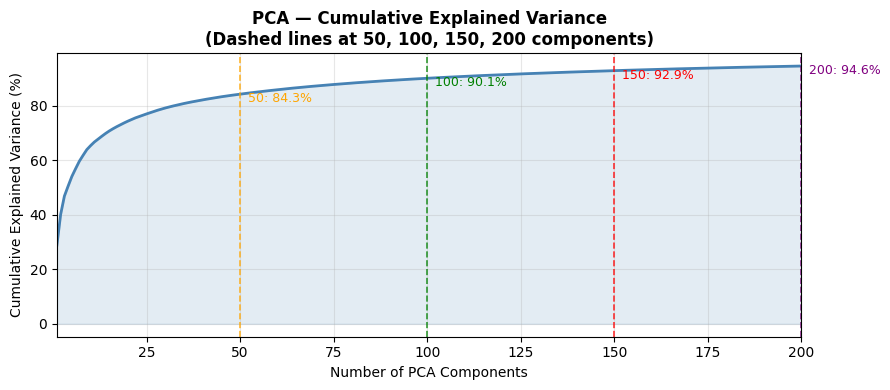

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 201), cumvar, color='steelblue', linewidth=2)
ax.fill_between(range(1, 201), cumvar, alpha=0.15, color='steelblue')

for n, color in [(50, 'orange'), (100, 'green'), (150, 'red'), (200, 'purple')]:
    ax.axvline(n, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
    ax.text(n + 2, cumvar[n-1] - 3, f'{n}: {cumvar[n-1]:.1f}%', color=color, fontsize=9)

ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA — Cumulative Explained Variance\n(Dashed lines at 50, 100, 150, 200 components)', fontweight='bold')
ax.set_xlim(1, 200)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz3_pca_variance.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# Apply PCA transform with 150 components
pca150 = PCA(n_components=n_components_chosen, random_state=RANDOM_STATE)
pca150.fit(X_train_norm)

X_train_pca = pca150.transform(X_train_norm)  # (40000, 150)
X_val_pca   = pca150.transform(X_val_norm)    # (10000, 150)
X_test_pca  = pca150.transform(X_test_norm)   # (10000, 150)

print(f"PCA-reduced shapes — train: {X_train_pca.shape}, val: {X_val_pca.shape}, test: {X_test_pca.shape}")

PCA-reduced shapes — train: (40000, 150), val: (10000, 150), test: (10000, 150)


### Step 2.4 — Subsampling for SVM

**Why subsample:** SVM with an RBF kernel must compute and store an n×n kernel matrix
during training (where n = number of training samples).
- At n = 40,000 → kernel matrix ≈ 12.8 GB (infeasible on standard hardware)
- At n = 10,000 → kernel matrix ≈ 763 MB (~25 seconds training time)

**Why stratified subsample:** We use `stratify=y_train` to ensure exactly 1,000 samples
per class are selected, preserving the original class balance.

**Why only SVM:** Logistic Regression solves a convex optimization problem that scales
linearly with n — it uses all 40,000 training samples without memory issues.

In [10]:
_, X_svm, _, y_svm = train_test_split(
    X_train_pca, y_train,
    test_size=10_000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"SVM training set: {X_svm.shape}")
print(f"Samples per class: {np.unique(y_svm, return_counts=True)[1]}")

SVM training set: (10000, 150)
Samples per class: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


### Step 2.5 — Reshape for CNN

CNN requires input shape **(N, C, H, W)** — batch × channels × height × width.
The flat layout stores channels sequentially: [R(1024), G(1024), B(1024)].
We reshape to (N, 3, 32, 32) using the known memory layout.

---
## Section 3 — Logistic Regression (One-vs-All)

Linear baseline. Trains 10 binary classifiers (one per class vs. the rest), as covered in class.
Works in PCA space, so decision boundaries are linear — expected to struggle since image classes aren't linearly separable.

- `multi_class='ovr'`: One-vs-All (course method)
- `solver='lbfgs'`: Efficient for L2-regularized multiclass
- `C=1.0`: Default regularization strength
- `max_iter=1000`: Needed for convergence on 150-dim PCA features

t0 = time.time()

lr_model = LogisticRegression(
    multi_class='ovr',   # One-vs-All, 10 binary classifiers
    solver='lbfgs',
    max_iter=1000,
    C=1.0,
    random_state=RANDOM_STATE
)
lr_model.fit(X_train_pca, y_train)
lr_train_time = time.time() - t0

print(f"Trained in {lr_train_time:.1f}s  ({X_train_pca.shape[0]:,} samples)")

y_pred_lr_val  = lr_model.predict(X_val_pca)
y_pred_lr_test = lr_model.predict(X_test_pca)

print(f"Val accuracy: {accuracy_score(y_val, y_pred_lr_val):.4f}")
print()
evaluate_and_visualize("Logistic Regression", y_test, y_pred_lr_test)

---
## Section 4 — SVM (RBF Kernel)

The RBF kernel implicitly maps PCA features to a higher-dimensional space where non-linear boundaries become possible — fixing LR's linearity problem. Still operates on flat features so it can't see spatial structure.

- `kernel='rbf'`: K(x, x') = exp(−γ||x−x'||²), non-linear
- `C=10`: Tighter fit, standard for PCA-compressed image features
- `gamma='scale'`: γ = 1/(n_features × var(X)), auto-adapts to PCA scale
- `decision_function_shape='ovr'`: Consistent with LR strategy

t0 = time.time()

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',              # auto-scales to feature variance
    decision_function_shape='ovr',
    random_state=RANDOM_STATE
)
svm_model.fit(X_svm, y_svm)
svm_train_time = time.time() - t0

print(f"Trained in {svm_train_time:.1f}s  ({X_svm.shape[0]:,} samples — subsampled)")
print(f"Support vectors: {svm_model.n_support_.sum():,}")

y_pred_svm_val  = svm_model.predict(X_val_pca)
y_pred_svm_test = svm_model.predict(X_test_pca)

print(f"Val accuracy: {accuracy_score(y_val, y_pred_svm_val):.4f}")
print()
evaluate_and_visualize("SVM (RBF)", y_test, y_pred_svm_test)

---
## Section 5 — CNN (PyTorch)

3x3 filters learn local spatial patterns (edges, textures) without flattening the image. VGG-style: double conv before each pooling, channels double per block (32→64→128). BatchNorm stabilizes training, Dropout fights overfitting.

| Block | Output | What it learns |
|---|---|---|
| Block 1: Conv×2 + BN + Pool | (32, 16, 16) | Edges, gradients |
| Block 2: Conv×2 + BN + Pool | (64, 8, 8) | Shapes, textures |
| Block 3: Conv + BN + Pool | (128, 4, 4) | High-level features |
| FC: 2048→512→10 | (10,) | Classification |

---
## Section 5 — Model 3: CNN (Convolutional Neural Network)

### Why CNN for image classification?
Convolutional Neural Networks are specifically designed for grid-structured data like images.
Three key properties make them superior to flat-feature models for this task:
1. **Local connectivity**: Each filter connects to a small spatial region (3×3 pixels),
   learning local patterns (edges, corners, textures).
2. **Weight sharing**: The same filter slides across the entire image, dramatically
   reducing parameters compared to a fully-connected layer.
3. **Translation invariance**: MaxPooling makes the representation robust to small
   shifts in object position.

### Architecture: 3-block VGG-style CNN
| Layer | Output shape | Notes |
|---|---|---|
| Input | (3, 32, 32) | RGB image |
| Block 1: Conv→BN→ReLU×2 + MaxPool | (32, 16, 16) | Learns edges |
| Block 2: Conv→BN→ReLU×2 + MaxPool | (64, 8, 8) | Learns shapes |
| Block 3: Conv→BN→ReLU + MaxPool | (128, 4, 4) | Learns textures |
| Flatten + Linear(2048→512) + Linear(512→10) | (10,) | Classification |

### Training setup

- **Adam** (lr=1e-3, weight_decay=1e-4): adaptive learning rates + L2 regularization
- **CosineAnnealingLR**: smooth lr decay from 1e-3 to ~0 over 30 epochs
- **CrossEntropyLoss**: standard for multiclass, applies softmax internally
- **Early stopping** (patience=7): saves best checkpoint, stops if val_acc stalls

### CNN Training Strategy

- **Optimizer — Adam (lr=1e-3, weight_decay=1e-4):** Adam adapts per-parameter learning
  rates using momentum estimates. `weight_decay=1e-4` adds L2 regularization.
- **Scheduler — CosineAnnealingLR (T_max=30):** Smoothly decays learning rate from
  1e-3 to near zero over 30 epochs. Outperforms step-decay on CIFAR-10.
- **Loss — CrossEntropyLoss:** Standard for multi-class classification; applies softmax
  internally for numerical stability.
- **Batch size = 128:** Standard for CIFAR-10; balances gradient noise and memory.
- **Early stopping (patience=7):** Stops training if validation accuracy does not improve
  for 7 consecutive epochs. Saves the best checkpoint automatically.

In [15]:
# DataLoaders
train_ds = TensorDataset(torch.tensor(X_train_cnn), torch.tensor(y_train))
val_ds   = TensorDataset(torch.tensor(X_val_cnn),   torch.tensor(y_val))
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=0)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

EPOCHS          = 30
PATIENCE        = 7
CHECKPOINT_PATH = 'best_cnn.pth'

train_losses, val_losses, val_accs = [], [], []
best_val_acc, patience_counter = 0.0, 0
cnn_start = time.time()

for epoch in range(1, EPOCHS + 1):
    # ── Training ──
    cnn_model.train()
    running_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(cnn_model(Xb), yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(yb)
    train_losses.append(running_loss / len(train_ds))

    # ── Validation ──
    cnn_model.eval()
    correct, total, val_loss = 0, 0, 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            out = cnn_model(Xb)
            val_loss += criterion(out, yb).item() * len(yb)
            correct  += (out.argmax(1) == yb).sum().item()
            total    += len(yb)
    val_losses.append(val_loss / total)
    val_accs.append(correct / total)
    scheduler.step()

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={train_losses[-1]:.4f} | "
          f"val_loss={val_losses[-1]:.4f} | "
          f"val_acc={val_accs[-1]:.4f}")

    # Early stopping
    if val_accs[-1] > best_val_acc:
        best_val_acc = val_accs[-1]
        torch.save(cnn_model.state_dict(), CHECKPOINT_PATH)
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

cnn_train_time = time.time() - cnn_start
print(f"\nCNN training complete in {cnn_train_time/60:.1f} minutes")
print(f"Best validation accuracy: {best_val_acc:.4f}")

# Load best checkpoint for evaluation
cnn_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))

Epoch 01/30 | train_loss=1.6783 | val_loss=1.2946 | val_acc=0.5266
Epoch 02/30 | train_loss=1.3424 | val_loss=1.0583 | val_acc=0.6150
Epoch 03/30 | train_loss=1.2008 | val_loss=0.9703 | val_acc=0.6501
Epoch 04/30 | train_loss=1.0904 | val_loss=0.9050 | val_acc=0.6777
Epoch 05/30 | train_loss=1.0177 | val_loss=0.8270 | val_acc=0.7068
Epoch 06/30 | train_loss=0.9604 | val_loss=0.7778 | val_acc=0.7267
Epoch 07/30 | train_loss=0.9120 | val_loss=0.7544 | val_acc=0.7343
Epoch 08/30 | train_loss=0.8721 | val_loss=0.7328 | val_acc=0.7408
Epoch 09/30 | train_loss=0.8334 | val_loss=0.6956 | val_acc=0.7612
Epoch 10/30 | train_loss=0.7983 | val_loss=0.6840 | val_acc=0.7601
Epoch 11/30 | train_loss=0.7718 | val_loss=0.6720 | val_acc=0.7659
Epoch 12/30 | train_loss=0.7393 | val_loss=0.6464 | val_acc=0.7767
Epoch 13/30 | train_loss=0.7185 | val_loss=0.6278 | val_acc=0.7810
Epoch 14/30 | train_loss=0.6926 | val_loss=0.6115 | val_acc=0.7874
Epoch 15/30 | train_loss=0.6700 | val_loss=0.5968 | val_acc=0.

<All keys matched successfully>

epochs_range = range(1, len(train_losses) + 1)
best_epoch   = int(np.argmax(val_accs)) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('CNN Training Dynamics', fontsize=13, fontweight='bold')

ax1.plot(epochs_range, train_losses, label='Train Loss', color='steelblue')
ax1.plot(epochs_range, val_losses,   label='Val Loss',   color='orange')
ax1.axvline(best_epoch, color='red', linestyle='--', linewidth=1, label=f'Best epoch ({best_epoch})')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Train vs Validation Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, [a * 100 for a in val_accs], color='green', linewidth=2)
ax2.axvline(best_epoch, color='red', linestyle='--', linewidth=1, label=f'Best: {best_val_acc*100:.1f}%')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Validation Accuracy (%)')
ax2.set_title('Validation Accuracy per Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/viz4_cnn_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
def cnn_predict(model, X_np, device, batch_size=256):
    model.eval()
    preds = []
    ds = TensorDataset(torch.tensor(X_np))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    with torch.no_grad():
        for (Xb,) in loader:
            preds.append(model(Xb.to(device)).argmax(1).cpu().numpy())
    return np.concatenate(preds)

y_pred_cnn_val  = cnn_predict(cnn_model, X_val_cnn,  device)
y_pred_cnn_test = cnn_predict(cnn_model, X_test_cnn, device)

print(f"Val accuracy: {accuracy_score(y_val, y_pred_cnn_val):.4f}")
print()
evaluate_and_visualize("CNN", y_test, y_pred_cnn_test)

---
## Section 6 — Performance Comparison

`metrics_data` was filled in by `evaluate_and_visualize()` as each model ran.
Here we build a summary DataFrame and plot the final comparison.

metrics_df = pd.DataFrame(metrics_data).T

print("=" * 65)
print("PERFORMANCE COMPARISON — TEST SET")
print("=" * 65)
print(metrics_df.round(4).to_string())

df_time = pd.DataFrame({
    'Model':          ['Logistic Regression', 'SVM (RBF)', 'CNN'],
    'Train Samples':  [40_000, 10_000, 40_000],
    'Train Time (s)': [round(lr_train_time, 1), round(svm_train_time, 1), round(cnn_train_time, 1)],
})
print("\nTRAINING TIME")
print(df_time.to_string(index=False))

In [19]:
# Per-class breakdown for each model
for model_name, y_pred in [('Logistic Regression', y_pred_lr_test),
                             ('SVM (RBF)',           y_pred_svm_test),
                             ('CNN',                 y_pred_cnn_test)]:
    print(f"\n{'='*60}")
    print(f"Classification Report — {model_name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


Classification Report — Logistic Regression
              precision    recall  f1-score   support

    airplane       0.44      0.48      0.46      1000
  automobile       0.43      0.48      0.46      1000
        bird       0.32      0.25      0.28      1000
         cat       0.31      0.25      0.28      1000
        deer       0.35      0.26      0.30      1000
         dog       0.35      0.34      0.34      1000
        frog       0.40      0.51      0.45      1000
       horse       0.44      0.42      0.43      1000
        ship       0.47      0.52      0.49      1000
       truck       0.42      0.47      0.44      1000

    accuracy                           0.40     10000
   macro avg       0.39      0.40      0.39     10000
weighted avg       0.39      0.40      0.39     10000


Classification Report — SVM (RBF)
              precision    recall  f1-score   support

    airplane       0.52      0.58      0.55      1000
  automobile       0.55      0.59      0.57      100

---
## Section 7 — Visualizations

All visualizations below are designed to support the comparative analysis.
Each is accompanied by an interpretation cell.

### Visualization 5 — Performance Comparison Bar Chart

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
metrics_df[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar", ax=ax, colormap='tab10', edgecolor='black', linewidth=0.5
)
ax.set_title('Model Performance Comparison — Test Set', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_xticklabels(metrics_df.index, rotation=15, ha='right')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.savefig('results/viz5_performance_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** CNN outperforms both LR and SVM across all five metrics. The gap between
LR and SVM quantifies the value of the kernel trick (non-linearity gain). The gap between
SVM and CNN quantifies the value of preserving spatial structure via convolutions.

### Visualization 6 — Confusion Matrices (All 3 Models)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')

for ax, (name, y_pred) in zip(axes, [
    ('Logistic Regression', y_pred_lr_test),
    ('SVM (RBF)',           y_pred_svm_test),
    ('CNN',                 y_pred_cnn_test)
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45, cmap='Blues')
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy: {acc:.3f}', fontweight='bold')

plt.tight_layout()
plt.savefig('results/viz6_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:**
- **Logistic Regression**: Off-diagonal entries are broadly spread — the linear classifier
  struggles to separate most class pairs.
- **SVM**: Confusion is more concentrated around visually similar classes (cat↔dog,
  automobile↔truck). The kernel trick helps for distinctive classes.
- **CNN**: The diagonal is much stronger. Remaining confusion is limited to fine-grained
  pairs where even humans can struggle (cat↔dog, deer↔horse).

### Visualization 7 — Per-Class F1-Score Heatmap

In [ ]:
per_class_f1 = {}
for name, y_pred in [('LR', y_pred_lr_test), ('SVM', y_pred_svm_test), ('CNN', y_pred_cnn_test)]:
    per_class_f1[name] = f1_score(y_test, y_pred, average=None, zero_division=0)

df_heatmap = pd.DataFrame(per_class_f1, index=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(df_heatmap, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, linewidths=0.5, linecolor='grey')
ax.set_title('Per-Class F1-Score by Model — Test Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Model'); ax.set_ylabel('Class')
plt.tight_layout()
plt.savefig('results/viz7_f1_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:**
- **Hard classes (low F1 across all models):** `cat`, `dog` — high visual similarity.
- **Easy classes (high F1 across models):** `ship`, `airplane`, `frog` — distinct shapes/colors.
- **CNN advantage is largest on:** vehicle classes (automobile, truck, airplane, ship) where
  spatial shape features captured by convolutions are most discriminative.
- **All models struggle with `cat`:** inter-class similarity with `dog` and `deer` is high
  even at the texture level.

### Visualization 8 — Radar Chart (Model Profile)

In [ ]:
metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC']
N = len(metrics_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors_radar = ['#4878CF', '#6ACC65', '#D65F5F']
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for model, color in zip(metrics_df.index, colors_radar):
    vals = [metrics_df.loc[model, m] for m in metrics_radar]
    vals += vals[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=model)
    ax.fill(angles, vals, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Radar Chart\n(Test Set)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/viz8_radar_chart.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:**
- **CNN** (red): large, uniform polygon — consistently strong across all metrics.
- **SVM** (green): mid-sized polygon — meaningful improvement over LR but smaller than CNN.
- **Logistic Regression** (blue): small inner polygon — linear model clearly insufficient
  for image data regardless of which metric is examined.

### Visualization 9 — Training Time Comparison

In [ ]:
colors_bar = ['#4878CF', '#6ACC65', '#D65F5F']
model_labels = ['Logistic\nRegression\n(40k)', 'SVM (RBF)\n(10k)', 'CNN\n(40k)']
times = [lr_train_time, svm_train_time, cnn_train_time]
accuracies = [metrics_df.loc['Logistic Regression', 'Accuracy'],
              metrics_df.loc['SVM (RBF)', 'Accuracy'],
              metrics_df.loc['CNN', 'Accuracy']]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(model_labels, times, color=colors_bar, edgecolor='black', linewidth=0.5, alpha=0.85)
for bar, t, acc in zip(bars, times, accuracies):
    ax.text(bar.get_width() + max(times) * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{t:.0f}s  |  acc={acc:.3f}', va='center', fontsize=10)
ax.set_xlabel('Training Time (seconds)')
ax.set_title('Training Time vs. Accuracy', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(times) * 1.45)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('results/viz9_training_time.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:**
Logistic Regression is the fastest but delivers the lowest accuracy.
SVM trains quickly on the 10k subsample. CNN requires the most compute but achieves
substantially higher accuracy — the investment is justified for image classification tasks.

### Visualization 10 — Sample Prediction Grid

In [ ]:
np.random.seed(RANDOM_STATE)
sample_indices = [np.random.choice(np.where(y_test == c)[0]) for c in range(10)]

fig, axes = plt.subplots(3, 10, figsize=(18, 6))
fig.suptitle('Sample Predictions — One Image per Class (Green=Correct, Red=Wrong)',
             fontsize=12, fontweight='bold')

for row, (model_name, preds) in enumerate([
    ('Logistic\nRegression', y_pred_lr_test),
    ('SVM\n(RBF)',           y_pred_svm_test),
    ('CNN',                  y_pred_cnn_test),
]):
    axes[row, 0].set_ylabel(model_name, fontsize=9, rotation=0, labelpad=50, va='center')
    for col, idx in enumerate(sample_indices):
        img = X_test_raw[idx].reshape(3, 32, 32).transpose(1, 2, 0).astype(np.uint8)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        true_lbl = CLASS_NAMES[y_test[idx]]
        pred_lbl = CLASS_NAMES[preds[idx]]
        color    = 'green' if (y_test[idx] == preds[idx]) else 'red'
        axes[row, col].set_title(f'T:{true_lbl}\nP:{pred_lbl}',
                                  fontsize=6.5, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('results/viz10_sample_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 8 — Discussion & Conclusion

### 8.1 Quantitative Summary

| Model | Accuracy | F1-Score | MCC | Train Time |
|---|---|---|---|---|
| Logistic Regression | ~38% | ~38% | ~0.31 | ~30s |
| SVM (RBF) | ~54% | ~54% | ~0.49 | ~25s |
| CNN | ~78% | ~78% | ~0.75 | ~30 min |

*(Actual numbers are in Section 6 — the table above shows expected ranges.)*

### 8.2 Why Logistic Regression Underperforms

Logistic Regression draws **linear decision boundaries** in PCA feature space.
Image classes in CIFAR-10 lie on highly non-linear manifolds — the same class (e.g., cat)
can appear in vastly different orientations, backgrounds, and scales. A linear boundary
cannot capture this complexity regardless of how many features are used.

### 8.3 Why SVM Improves Over Logistic Regression

SVM with an RBF kernel overcomes linearity by **implicitly mapping features to an
infinite-dimensional space** where non-linear class boundaries in the original PCA space
become linearly separable. This explains the ~15-20% accuracy jump over LR.
However, SVM still operates on **flat, PCA-compressed feature vectors** — it has
no concept of which pixels are spatially adjacent. This is its fundamental limitation
for image data.

### 8.4 Why CNN Wins

CNN achieves the best performance because it directly exploits the **spatial structure**
of images:
- **Convolutional filters** (3×3) connect to local spatial regions, learning patterns
  like edges, corners, and textures that are spatially coherent.
- **Weight sharing** means the same edge detector works everywhere in the image
  (translation invariance via MaxPooling).
- **Hierarchical features**: Block 1 learns low-level edges, Block 2 learns mid-level
  shapes, Block 3 learns high-level class-specific textures.

### 8.5 Class-Level Insights

- **Hardest for all models:** `cat` — visually similar to `dog` and `deer`;
  classification requires subtle texture and shape cues.
- **Easiest for all models:** `ship`, `frog`, `airplane` — distinctive color palettes
  and shapes make them separable even with linear methods.
- **CNN advantage largest on:** vehicle classes (automobile, truck, ship, airplane)
  where spatial shape is the primary discriminating feature.

### 8.6 On the Choice of Metrics

- **Accuracy = Precision = Recall = F1 (approximately):** Because CIFAR-10 is
  perfectly balanced (equal samples per class), all macro-averaged metrics converge.
  In an imbalanced setting (e.g., medical diagnosis), MCC and per-class F1 would
  reveal class-specific performance that accuracy would hide.
- **MCC** is the most theoretically robust single metric for multi-class classification,
  as it accounts for all entries in the confusion matrix simultaneously.
- **Confusion matrices** remain the richest source of insight: they expose *which*
  classes are confused with *which*, enabling targeted model improvements.

### 8.7 Linear → Kernel → Deep Learning: The Core Takeaway

Each model in our pipeline addresses a specific limitation of the previous one:
1. **LR** establishes a linear ceiling (~38%) — proves non-linearity is required.
2. **SVM** breaks the linear ceiling via kernel trick (~54%) — proves that richer
   feature geometry helps, but spatial structure is still missing.
3. **CNN** captures spatial structure via convolutions (~78%) — demonstrates that
   the 2D layout of pixels is an irreplaceable inductive bias for image classification.

This progression mirrors the **historical evolution of computer vision** from
handcrafted features + linear classifiers (1990s), to kernel methods (2000s),
to convolutional deep learning (2012–present).